In [1]:
"""Uncomment and run this cell if dataset not in local disk"""
# from datasets import load_dataset

# imdb = load_dataset("imdb")
# imdb.save_to_disk("../data/imdb_dataset")  # saves to a local folder

'Uncomment and run this cell if dataset not in local disk'

In [2]:
"""save dataset as csv in the local directory"""
# from datasets import load_from_disk
# import pandas as pd

# imdb = load_from_disk("../data/imdb_dataset") # load dataset from folder

# #Convert to pandas DataFrame
# train_dataframe = pd.DataFrame(imdb['train'])
# test_dataframe = pd.DataFrame(imdb['test'])

# train_dataframe.to_csv("../data/csv/train.csv", index=False)
# test_dataframe.to_csv("../data/csv/test.csv", index=False)

'save dataset as csv in the local directory'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
)
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [4]:
train_csv_path = "../data/csv/train.csv"
test_csv_path = "../data/csv/test.csv"
model_name = "distilbert-base-uncased"

In [5]:
train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)

In [6]:
train_df.head()

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [7]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    25000 non-null  str  
 1   label   25000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 32.0 MB


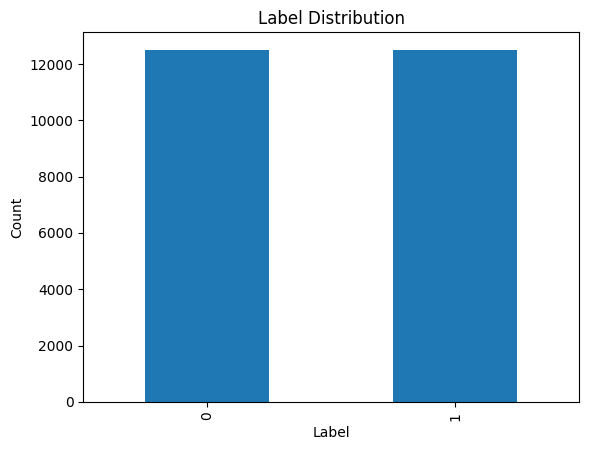

In [8]:
train_df["label"].value_counts().plot(kind="bar")
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [9]:
train_df["text_length"] = train_df["text"].apply(len)

<Figure size 600x400 with 0 Axes>

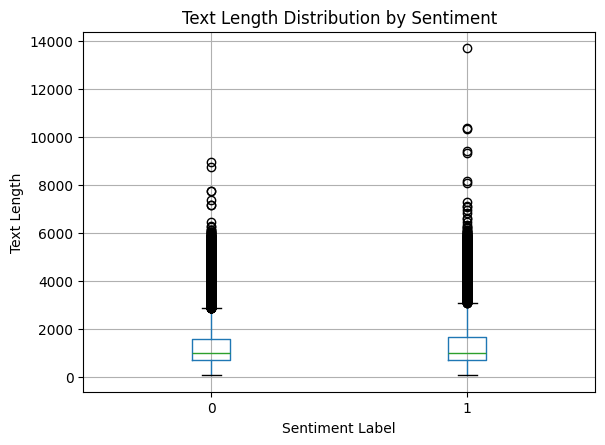

In [10]:
plt.figure(figsize=(6,4))
train_df.boxplot(column="text_length", by="label")
plt.title("Text Length Distribution by Sentiment")
plt.suptitle("")
plt.xlabel("Sentiment Label")
plt.ylabel("Text Length")
plt.show()

In [12]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)       # remove URLs
    text = re.sub(r"<.*?>", "", text)         # remove HTML
    text = re.sub(r"[^a-zA-Z\s]", "", text)   # remove special chars
    text = re.sub(r"\s+", " ", text).strip()  # remove extra spaces

    return text


train_df["text"] = train_df["text"].apply(clean_text)
test_df["text"] = test_df["text"].apply(clean_text)

In [13]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_df["token_length"] = train_df["text"].apply(
    lambda x: len(tokenizer.tokenize(x))
)

Token indices sequence length is longer than the specified maximum sequence length for this model (554 > 512). Running this sequence through the model will result in indexing errors


<Axes: >

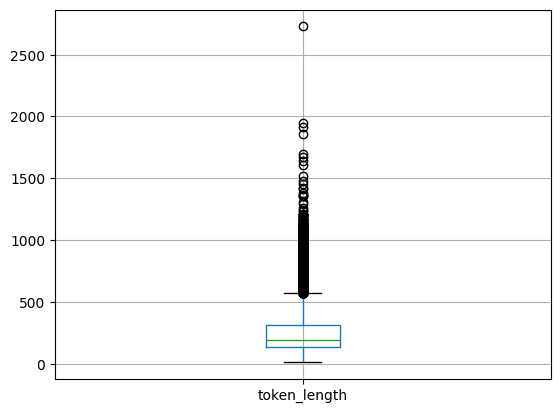

In [14]:
train_df.boxplot(column="token_length")

In [15]:
train_df = train_df[train_df["token_length"] < 512] 

In [16]:
train_df.info()

<class 'pandas.DataFrame'>
Index: 22624 entries, 0 to 24999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   text          22624 non-null  str  
 1   label         22624 non-null  int64
 2   text_length   22624 non-null  int64
 3   token_length  22624 non-null  int64
dtypes: int64(3), str(1)
memory usage: 22.6 MB


In [17]:
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [ ]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)


def tokenize_function(example):

    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=256        # 512 is used for capture more context but train time will be high, for fast training use 256
    )


train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map: 100%|██████████| 25000/25000 [00:03<00:00, 6597.41 examples/s]


In [19]:
train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

In [21]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 5620.43it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [24]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary"
    )

    acc = accuracy_score(labels, predictions)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [29]:
training_args = TrainingArguments(

    output_dir="../model",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    save_strategy="epoch"
)

In [31]:
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,
    eval_dataset=test_dataset,

    processing_class=tokenizer,

    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

c:\Users\HP\OneDrive - University of Moratuwa\Desktop\ML-Project\Sentiment_Classifier\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


In [ ]:
results = trainer.evaluate()

print("\nEvaluation Results")
print(results)

In [ ]:
trainer.save_model("../model")

tokenizer.save_pretrained("../model")

print("\nModel saved to sentiment_model/")